In [1]:
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import jax.random as jr
import equinox as eqx
import optax
from jax import grad, vmap

jax.config.update("jax_enable_x64", True)
plt.rcParams["figure.dpi"] = 140

In [2]:
# BOOK_FIGURE_STYLE_CELL
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

try:
    import seaborn as sns
except ImportError:
    sns = None

try:
    import matplotlib_inline

    matplotlib_inline.backend_inline.set_matplotlib_formats("svg", "pdf")
except Exception:
    matplotlib_inline = None

FIGURE_SIZES = {
    # The print text block is 4.5 inches wide.
    "full_landscape": (4.50, 2.65),
    "full_standard": (7.35, 4.90),
    "full_tall": (7.35, 5.50),
    "half_standard": (3.55, 2.55),
    "half_tall": (3.55, 3.05),
    "inset": (2.30, 1.75),
}

BOOK_COLORS = {
    "blue": "#4C78A8",
    "orange": "#F58518",
    "green": "#54A24B",
    "red": "#E45756",
    "gray": "#7F7F7F",
}

BOOK_TARGET = "web"


def setup_book_style(target="web"):
    global BOOK_TARGET
    BOOK_TARGET = target
    mpl.rcParams.update(
        {
            "figure.figsize": FIGURE_SIZES["half_standard"],
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "savefig.bbox": "tight",
            "savefig.pad_inches": 0.02,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
            "font.family": "sans-serif",
            "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
            "axes.labelsize": 9,
            "axes.titlesize": 9,
            "axes.linewidth": 0.8,
            "axes.grid": False,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "xtick.labelsize": 8,
            "ytick.labelsize": 8,
            "xtick.major.width": 0.8,
            "ytick.major.width": 0.8,
            "legend.fontsize": 8,
            "legend.frameon": False,
            "lines.linewidth": 1.5,
            "lines.markersize": 4,
            "patch.linewidth": 0.8,
            "image.cmap": "Greys",
        }
    )
    if target == "latex":
        try:
            mpl.rcParams["text.usetex"] = False
        except Exception:
            mpl.rcParams["text.usetex"] = False


def new_figure(
    size="half_standard",
    nrows=1,
    ncols=1,
    sharex=False,
    sharey=False,
    constrained=True,
    squeeze=True,
    **kwargs,
):
    fig, ax = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        sharex=sharex,
        sharey=sharey,
        constrained_layout=constrained,
        figsize=FIGURE_SIZES[size],
        squeeze=squeeze,
        **kwargs,
    )
    return fig, ax


def label_panels(axes=None, labels=None, x=0.02, y=0.98, **kwargs):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    if labels is None:
        labels = [f"({chr(97 + i)})" for i in range(len(axes))]
    default = dict(
        fontsize=9,
        fontweight="bold",
        va="top",
        ha="left",
        transform=None,
        bbox=dict(facecolor="white", edgecolor="none", pad=0.8, alpha=0.9),
    )
    default.update(kwargs)
    for ax, label in zip(axes, labels):
        call_kwargs = dict(default)
        if call_kwargs["transform"] is None:
            call_kwargs["transform"] = ax.transAxes
        ax.text(x, y, label, **call_kwargs)


def finalize_axes(axes=None, keep_box=False, grid=False):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        if grid:
            ax.grid(axis="y", color="0.88", linewidth=0.6)
        else:
            ax.grid(False)
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)
        if keep_box:
            ax.spines["top"].set_visible(True)
            ax.spines["right"].set_visible(True)
        else:
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
    return axes


def save_book_figure(fig, basename, target="web", pdf=True, png=False):
    base = Path(basename)
    base.parent.mkdir(parents=True, exist_ok=True)
    if pdf:
        fig.savefig(base.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
    if png:
        fig.savefig(base.with_suffix(".png"), bbox_inches="tight", pad_inches=0.02)


setup_book_style(target="web")


# Physics-Informed Neural Operators


A DeepONet can learn a map from one function to another using paired input-output examples {cite:t}`lu2021learning`. Full paired solution data can be expensive, whereas the governing equations are usually available.

Physics-informed neural operators learn an operator from data and regularize training with the residual of the underlying differential equation. {cite:t}`li2021pino` develop this construction for Fourier-type operator architectures. We implement the same principle with a small DeepONet that is easy to derive and fast enough to run on a laptop.

The example isolates how a PDE residual can improve the data efficiency of operator learning.



## A parametric Poisson operator

Consider the family of boundary value problems

$$
\begin{aligned}
-u''(x) &= f(x), \quad x \in (0,1),\\
u(0) &= 0,\\
u(1) &= 0.
\end{aligned}
$$

The input is the forcing function $f$, and the output is the solution $u$. This is an **operator** because it maps one function to another.

To keep the notebook simple, we generate $f$ from a short sine expansion:

$$
f(x) = \sum_{m=1}^3 a_m \sin(m\pi x).
$$

For this family the exact solution is also available analytically:

$$
u(x) = \sum_{m=1}^3 \frac{a_m}{(m\pi)^2}\sin(m\pi x).
$$

We will use this only to generate a synthetic dataset. The learning problem is still meaningful: from a small number of examples, can we infer the operator that maps a forcing function to its solution?

In [3]:
n_modes = 3
n_sensors = 32
n_label = 4
n_colloc = 24
n_train = 24
n_test = 16

xs_sensor = jnp.linspace(0.0, 1.0, n_sensors)
xs_label = jnp.linspace(0.15, 0.85, n_label)
xs_colloc = jnp.linspace(0.0, 1.0, n_colloc + 2)[1:-1]
xs_eval = jnp.linspace(0.0, 1.0, 128)

modes = jnp.arange(1, n_modes + 1)

def forcing(coeffs, x):
    return jnp.sum(coeffs * jnp.sin(jnp.pi * modes * x))

def solution(coeffs, x):
    return jnp.sum(coeffs * jnp.sin(jnp.pi * modes * x) / ((jnp.pi * modes) ** 2))

v_forcing = vmap(lambda x, coeffs: forcing(coeffs, x), in_axes=(0, None))
v_solution = vmap(lambda x, coeffs: solution(coeffs, x), in_axes=(0, None))

def build_dataset(key, n_functions):
    coeffs = jr.normal(key, (n_functions, n_modes)) * jnp.array([1.0, 0.5, 0.25])
    sensor_values = vmap(lambda c: v_forcing(xs_sensor, c))(coeffs)
    label_values = vmap(lambda c: v_solution(xs_label, c))(coeffs)
    rhs_values = vmap(lambda c: v_forcing(xs_colloc, c))(coeffs)
    eval_values = vmap(lambda c: v_solution(xs_eval, c))(coeffs)
    return coeffs, sensor_values, label_values, rhs_values, eval_values

key = jr.PRNGKey(0)
key, train_key, test_key, model_key = jr.split(key, 4)
train_coeffs, train_sensors, train_labels, train_rhs, train_truth = build_dataset(train_key, n_train)
test_coeffs, test_sensors, test_labels, test_rhs, test_truth = build_dataset(test_key, n_test)

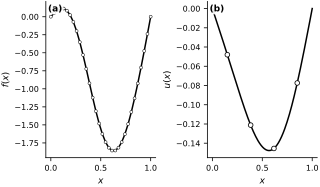

In [4]:
fig, axes = new_figure("full_landscape", ncols=2, sharex=True)
example_id = 0
axes[0].plot(xs_sensor, train_sensors[example_id], color="black")
axes[0].scatter(
    xs_sensor, train_sensors[example_id], s=9, facecolors="white",
    edgecolors="black", linewidths=0.5, zorder=3
)
axes[0].set(xlabel=r'$x$', ylabel=r'$f(x)$')

axes[1].plot(xs_eval, train_truth[example_id], color="black")
axes[1].scatter(
    xs_label, train_labels[example_id], s=22, facecolors="white",
    edgecolors="black", linewidths=0.8, zorder=3
)
axes[1].set(xlabel=r'$x$', ylabel=r'$u(x)$')
label_panels(axes)
finalize_axes(axes)
plt.show()

Each forcing function is discretized on a fixed set of branch-sensor locations. The DeepONet will take those sensor values as input, together with a query point $x$, and return a prediction of the solution at that point.

We reveal only **four labeled solution values per training function**. A purely supervised operator learner must infer the whole solution operator from these sparse paired data.

## A small DeepONet

The architecture uses the same branch-trunk decomposition we used earlier, multiplied by $x(1-x)$ so that every prediction satisfies the two homogeneous boundary conditions exactly:

$$
G_\theta(f)(x) = x(1-x)\left[\langle b_\theta(f), t_\theta(x) \rangle + c\right].
$$

The branch network compresses the input function samples. The trunk network represents the query location. Their inner product produces the unconstrained output, while the prefactor enforces $G_\theta(f)(0)=G_\theta(f)(1)=0$. Applying the same hard constraint to both models keeps the comparison focused on the interior PDE residual.

We will train two versions of this same architecture.

1. A **supervised DeepONet** that uses only the sparse labeled pairs.
2. A **physics-informed DeepONet** that uses the same labeled pairs plus the PDE residual

$$
r(f, x) = -\frac{d^2}{dx^2}G_\theta(f)(x) - f(x).
$$

This is the operator-learning analogue of the PINN residual from the previous notebooks.

In [5]:
latent_size = 32
width_size = 64
depth = 2

class DeepONet(eqx.Module):
    branch: eqx.nn.MLP
    trunk: eqx.nn.MLP
    bias: jax.Array

    def __init__(self, key):
        branch_key, trunk_key = jr.split(key)
        self.branch = eqx.nn.MLP(n_sensors, latent_size, width_size, depth, jax.nn.tanh, key=branch_key)
        self.trunk = eqx.nn.MLP(1, latent_size, width_size, depth, jax.nn.tanh, key=trunk_key)
        self.bias = jnp.array(0.0)

    def __call__(self, sensor_values, x):
        branch_state = self.branch(sensor_values)
        trunk_state = self.trunk(jnp.array([x]))
        return x * (1.0 - x) * (jnp.dot(branch_state, trunk_state) + self.bias)

supervised_model = DeepONet(model_key)
physics_model = DeepONet(model_key)

In [6]:
u_x = grad(lambda x, model, sensor_values: model(sensor_values, x), argnums=0)
u_xx = grad(u_x, argnums=0)

def supervised_loss(model, sensors_batch, labels_batch):
    preds = vmap(lambda s: vmap(lambda x: model(s, x))(xs_label))(sensors_batch)
    data_loss = jnp.mean((preds - labels_batch) ** 2)
    return data_loss, (data_loss, jnp.array(0.0))

def physics_informed_loss(model, sensors_batch, labels_batch, rhs_batch, lambda_pde=0.1):
    preds = vmap(lambda s: vmap(lambda x: model(s, x))(xs_label))(sensors_batch)
    data_loss = jnp.mean((preds - labels_batch) ** 2)
    residual_values = vmap(
        lambda sensor_values, rhs_values: vmap(
            lambda x, rhs: -u_xx(x, model, sensor_values) - rhs
        )(xs_colloc, rhs_values)
    )(sensors_batch, rhs_batch)
    pde_loss = jnp.mean(residual_values ** 2)
    total_loss = data_loss + lambda_pde * pde_loss
    return total_loss, (data_loss, pde_loss)

## Training the supervised and physics-informed models

The only difference between the two models is the loss function. They see the same sparse paired data and both satisfy the boundary conditions by construction. The physics-informed model gets extra information only through the PDE residual at interior collocation points.

If the physics term helps, it should appear as better test-time operator generalization, not just lower training loss.

In [7]:
optimizer = optax.adam(1e-3)
supervised_state = optimizer.init(eqx.filter(supervised_model, eqx.is_inexact_array))
physics_state = optimizer.init(eqx.filter(physics_model, eqx.is_inexact_array))

@eqx.filter_jit
def supervised_step(model, optimizer_state, sensors_batch, labels_batch):
    (loss_value, aux), grads = eqx.filter_value_and_grad(supervised_loss, has_aux=True)(
        model, sensors_batch, labels_batch
    )
    updates, optimizer_state = optimizer.update(grads, optimizer_state, model)
    model = eqx.apply_updates(model, updates)
    return model, optimizer_state, loss_value, aux

@eqx.filter_jit
def physics_step(model, optimizer_state, sensors_batch, labels_batch, rhs_batch):
    (loss_value, aux), grads = eqx.filter_value_and_grad(physics_informed_loss, has_aux=True)(
        model, sensors_batch, labels_batch, rhs_batch
    )
    updates, optimizer_state = optimizer.update(grads, optimizer_state, model)
    model = eqx.apply_updates(model, updates)
    return model, optimizer_state, loss_value, aux

n_steps = 2500
batch_size = 8
history = {
    "supervised": [],
    "physics": [],
    "physics_data": [],
    "physics_pde": [],
}

for step in range(n_steps):
    key, batch_key = jr.split(key)
    batch_idx = jr.choice(batch_key, n_train, (batch_size,), replace=False)
    sensors_batch = train_sensors[batch_idx]
    labels_batch = train_labels[batch_idx]
    rhs_batch = train_rhs[batch_idx]

    supervised_model, supervised_state, supervised_value, _ = supervised_step(
        supervised_model, supervised_state, sensors_batch, labels_batch
    )
    physics_model, physics_state, physics_value, physics_aux = physics_step(
        physics_model, physics_state, sensors_batch, labels_batch, rhs_batch
    )

    history["supervised"].append(float(supervised_value))
    history["physics"].append(float(physics_value))
    history["physics_data"].append(float(physics_aux[0]))
    history["physics_pde"].append(float(physics_aux[1]))

    if step % 500 == 0 or step == n_steps - 1:
        print(
            f"step={step:4d} "
            f"supervised={float(supervised_value):.6f} "
            f"physics={float(physics_value):.6f} "
            f"pde={float(physics_aux[1]):.6f}"
        )

step=   0 supervised=0.011362 physics=0.127555 pde=1.161934


step= 500 supervised=0.000007 physics=0.000226 pde=0.002165


step=1000 supervised=0.000006 physics=0.000025 pde=0.000245


step=1500 supervised=0.000001 physics=0.000876 pde=0.008061


step=2000 supervised=0.000001 physics=0.000017 pde=0.000165


step=2499 supervised=0.000011 physics=0.000121 pde=0.001125


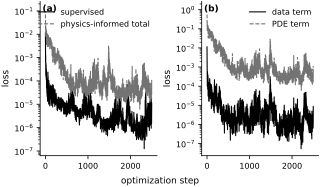

In [8]:
fig, axes = new_figure("full_landscape", ncols=2, sharex=True)

axes[0].semilogy(
    history["supervised"], color="black", linestyle="-",
    linewidth=1.1, label="supervised"
)
axes[0].semilogy(
    history["physics"], color="0.45", linestyle="--",
    linewidth=1.1, label="physics-informed total"
)
axes[0].set_ylabel("loss")
axes[0].legend(loc="upper right")

axes[1].semilogy(
    history["physics_data"], color="black", linestyle="-",
    linewidth=1.1, label="data term"
)
axes[1].semilogy(
    history["physics_pde"], color="0.45", linestyle="--",
    linewidth=1.1, label="PDE term"
)
axes[1].set_ylabel("loss")
axes[1].legend(loc="upper right")
fig.supxlabel("optimization step", fontsize=9)
label_panels(axes)
finalize_axes(axes)
plt.show()

## Test-time operator accuracy

We now evaluate both models on unseen forcing functions. This is the real target: how well do they generalize as operators?

We report the relative $L^2$ error on a dense evaluation grid for each test function and compare the average error of the two methods.

In [9]:
def predict_grid(model, sensor_values):
    return vmap(lambda x: model(sensor_values, x))(xs_eval)

supervised_preds = vmap(lambda s: predict_grid(supervised_model, s))(test_sensors)
physics_preds = vmap(lambda s: predict_grid(physics_model, s))(test_sensors)

relative_error = lambda pred, truth: jnp.linalg.norm(pred - truth) / jnp.linalg.norm(truth)
supervised_errors = vmap(relative_error)(supervised_preds, test_truth)
physics_errors = vmap(relative_error)(physics_preds, test_truth)

print(f"Mean relative L2 error (supervised):       {supervised_errors.mean():.4f}")
print(f"Mean relative L2 error (physics-informed): {physics_errors.mean():.4f}")

Mean relative L2 error (supervised):       0.0916
Mean relative L2 error (physics-informed): 0.0492


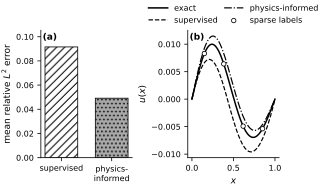

In [10]:
test_id = int(jnp.argmax(supervised_errors - physics_errors))

fig, axes = new_figure("full_landscape", ncols=2)

mean_errors = np.asarray([supervised_errors.mean(), physics_errors.mean()])
bars = axes[0].bar(
    np.arange(2), mean_errors, width=0.65,
    facecolor=["white", "0.65"], edgecolor="black", linewidth=0.8
)
for bar, hatch in zip(bars, ["///", "..."]):
    bar.set_hatch(hatch)
axes[0].set_xticks(np.arange(2), ["supervised", "physics-\ninformed"])
axes[0].set_ylabel(r'mean relative $L^2$ error')
axes[0].margins(y=0.15)

axes[1].plot(
    xs_eval, test_truth[test_id], color="black", linestyle="-",
    linewidth=1.5, label="exact"
)
axes[1].plot(
    xs_eval, supervised_preds[test_id], color="black", linestyle="--",
    linewidth=1.2, label="supervised"
)
axes[1].plot(
    xs_eval, physics_preds[test_id], color="black", linestyle="-.",
    linewidth=1.2, label="physics-informed"
)
axes[1].scatter(
    xs_label, test_labels[test_id], s=20, facecolors="white",
    edgecolors="black", linewidths=0.8, zorder=3, label="sparse labels"
)
axes[1].set(xlabel=r'$x$', ylabel=r'$u(x)$')
axes[1].legend(
    loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2,
    borderaxespad=0.0, columnspacing=0.8, handlelength=2.4
)
label_panels(axes)
finalize_axes(axes)
plt.show()

In this sparse-data regime, the physics-informed model generalizes better because the PDE residual supplies information about the shape of the solution between the labeled points and across functions.

This also clarifies the relationship between PINNs and neural operators.

- A PINN learns one solution of one PDE instance by enforcing a residual.
- A neural operator learns a map from many PDE instances to their solutions.
- A physics-informed neural operator does both: it learns the map across instances while using the governing equations to reduce how much paired data it needs.

The same construction applies to other operator architectures. {cite:t}`li2021pino` use it with Fourier-style architectures on larger PDE datasets.

## Exercises

1. Increase `n_train` while keeping `n_label = 4`. At what point does the purely supervised operator start to catch up?
2. Increase `n_label` from `4` to `8`. Does the benefit of the PDE residual shrink as more paired data become available?
3. Change the residual weight in `physics_informed_loss`. Can you make the physics-informed model worse by weighting the PDE term too strongly?
4. Increase the number of sine modes used to generate the forcing functions. Does the same architecture still generalize well, or do you need more branch sensors and a larger latent space?
5. Replace the DeepONet with the FNO implementation from the previous operator-learning notebook. Does the same physics-informed training idea still help?